# Notebook 2 — Berkson's Paradox & Selection Distortion
**Modeling Social Behavior** | Smaldino

--- 

Before we talk about publication bias in the Bayesian model,  
we need to understand *why* selection creates spurious correlations.  
This notebook — translated from the R script `berkson_sim.R` — demonstrates  
**Berkson's Paradox** with a clean, visual simulation.

---

## 🧠 Conceptual Overview

### What is Berkson's Paradox?

Berkson's Paradox is the observation that **conditioning on a collider variable creates a spurious correlation** between two otherwise independent variables.

In plain terms: if you select cases *because* they score high on a combination of two traits, those two traits will appear *negatively correlated* within your selected sample even if they're completely uncorrelated in the full population.

---

### The setup for science

Imagine every research paper has two independent properties:

- **Trustworthiness (T)** — methodological rigor, replicability, honest reporting
- **Newsworthiness (W)** — exciting claims, large effect sizes, counterintuitive findings

In the full population of conducted studies, these two properties are *uncorrelated*, a rigorously designed study isn't inherently more or less exciting than a sloppy one.

**But:** journals select papers based on *both* qualities. A paper needs to clear a threshold on the *sum* T + W to get published.

This selection creates a **collider structure**:

```
Trustworthiness → [Published?] ← Newsworthiness
```

### Why does this produce a negative correlation?

Consider the published papers. To get published with *low* trustworthiness, a paper must have *high* newsworthiness (to compensate). To get published with *high* trustworthiness, a paper can afford *lower* newsworthiness. Within the selected group, T and W must trade off — creating an artifactual negative correlation.

**The consequence:** Among published papers, the most newsworthy findings tend to be the *least* trustworthy. Science's filtering mechanism works against itself.

---

### Connection to Berkson (1946)

Joseph Berkson noticed the same phenomenon in hospital patients: among hospitalized patients, two diseases can appear negatively correlated even if they're independent in the general population — because being hospitalized requires *some* condition to be serious.

---

### Why does this matter for science?

1. Replication failures — the flashiest results are systematically less reliable  
2. "Decline effect" — effect sizes shrink as more rigorous replications follow  
3. Incentive distortion — scientists learn that exciting claims get rewarded, rigor is secondary  
4. Reviewer and editor selection creates the collider, even unintentionally  


## Setup — Imports

In [1]:
# ── Standard scientific Python stack ──────────────────────────────────────
import numpy as np                  # array operations and random sampling
import matplotlib.pyplot as plt     # plotting
import matplotlib.patches as mpatches  # for custom legend
from scipy import stats             # for correlation and linear regression

# Reproducibility
np.random.seed(2024)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Parameters

### Variable types
- **Global variables:** `M`, `M_top`, `selection_threshold_pct`  
  These control the size of the simulated paper population and the selectivity of the journal.

There are no agents in this model. It is a **statistical / analytical simulation**  
— we generate a dataset and then examine what selection does to the correlation structure.


In [2]:
# ── GLOBAL VARIABLES ──────────────────────────────────────────────────────

M = 500                        # Total number of papers submitted / considered
                               # (mirrors R script: M <- 500)

selection_threshold_pct = 0.10 # Top X% of papers get published
                               # Default: top 10% (mirrors R: M_top <- round(M/10))

M_top = round(M * selection_threshold_pct)  # Number of papers that get accepted

print(f"Total papers:    {M}")
print(f"Papers accepted: {M_top} ({selection_threshold_pct*100:.0f}% acceptance rate)")


Total papers:    500
Papers accepted: 50 (10% acceptance rate)


## Generate the Paper Population

We draw trustworthiness (T) and newsworthiness (W) independently from a standard normal distribution.  
Independence is the key assumption: in the full population, these traits have *no* inherent relationship.


In [3]:
# ── Generate paper properties ─────────────────────────────────────────────
# Both drawn from standard normal N(0,1) — independent of each other.
# LOCAL variables (within this cell, then stored for later use)

trustworthiness = np.random.normal(0, 1, M)   # T scores for all M papers
newsworthiness  = np.random.normal(0, 1, M)   # W scores for all M papers

# ── Compute the selection score: S = T + W ────────────────────────────────
# Papers are selected based on the *sum* of both qualities.
# This is the collider: to be published, a paper must clear a threshold on S.

score = trustworthiness + newsworthiness       # S = T + W (selection criterion)

# ── Rank and select top M_top papers ─────────────────────────────────────
# argsort in descending order; take first M_top indices
ranked_indices    = np.argsort(score)[::-1]   # all papers ranked best→worst
selected_indices  = ranked_indices[:M_top]    # top M_top papers
rejected_indices  = ranked_indices[M_top:]    # remaining papers

# ── Verify independence in the full population ────────────────────────────
r_all, p_all = stats.pearsonr(trustworthiness, newsworthiness)
print(f"Correlation in FULL population (all {M} papers):  r = {r_all:.4f}, p = {p_all:.3f}")
print("→ As expected, essentially 0 (independently drawn).")

# ── Compute correlation in the selected (published) papers ────────────────
T_sel = trustworthiness[selected_indices]
W_sel = newsworthiness[selected_indices]
r_sel, p_sel = stats.pearsonr(T_sel, W_sel)
print(f"\nCorrelation in SELECTED papers (top {M_top}):       r = {r_sel:.4f}, p = {p_sel:.4f}")
print("→ Negative and significant! Berkson's Paradox in action.")


Correlation in FULL population (all 500 papers):  r = -0.0296, p = 0.509
→ As expected, essentially 0 (independently drawn).

Correlation in SELECTED papers (top 50):       r = -0.6305, p = 0.0000
→ Negative and significant! Berkson's Paradox in action.


## Visualization 1 — The Full Population (No Selection)

All papers shown in gray. No correlation structure visible — as designed.


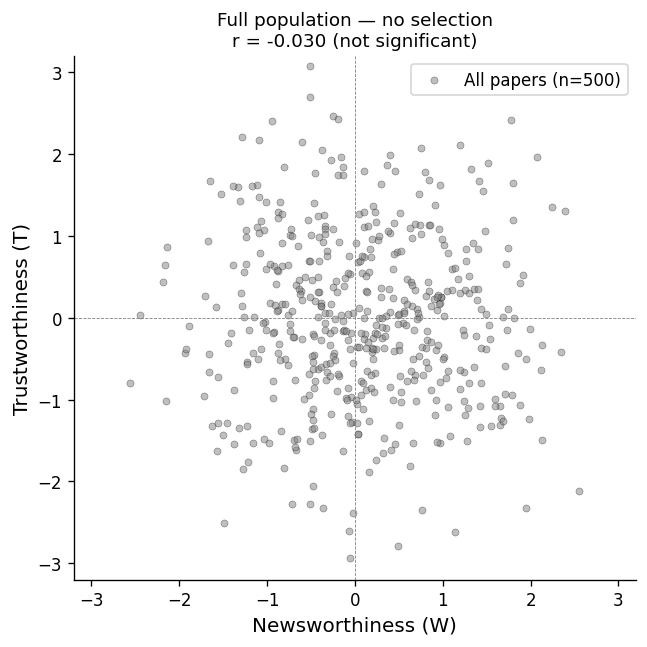

In [4]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))

# Plot all papers
ax.scatter(newsworthiness, trustworthiness,
           color="gray", alpha=0.5, s=18, edgecolors="black", linewidths=0.3,
           label=f"All papers (n={M})")

ax.set_xlabel("Newsworthiness (W)", fontsize=12)
ax.set_ylabel("Trustworthiness (T)", fontsize=12)
ax.set_title(f"Full population — no selection\nr = {r_all:.3f} (not significant)", fontsize=11)
ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2)
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


## Visualization 2 — After Selection (Published Papers Highlighted)

The green dots are the papers that made it into the journal (top 10% by T + W).  
A regression line through the green points reveals the negative correlation.


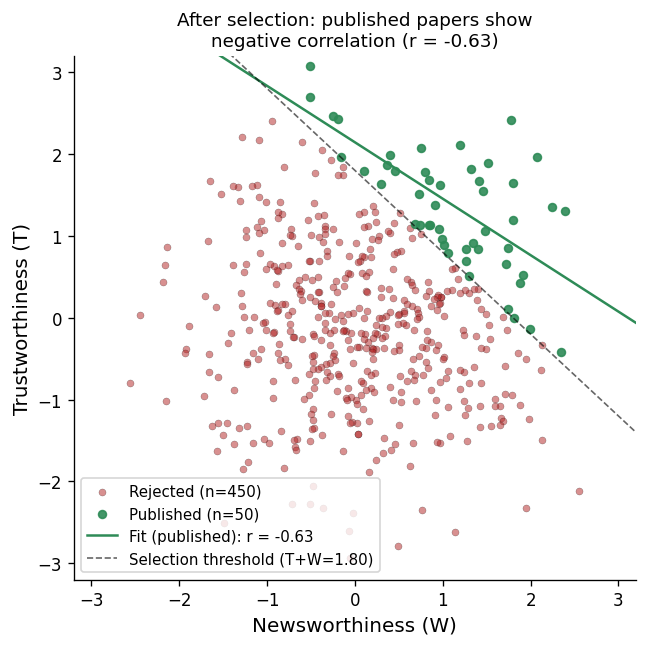

Selection threshold score: T + W ≥ 1.80
Correlation among published: r = -0.6305  (p = 9.2284e-07)


In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))

# ── Rejected papers in red ────────────────────────────────────────────────
ax.scatter(newsworthiness[rejected_indices], trustworthiness[rejected_indices],
           color="firebrick", alpha=0.5, s=18, marker="o",
           edgecolors="black", linewidths=0.2,
           label=f"Rejected (n={M - M_top})")

# ── Accepted papers in green ──────────────────────────────────────────────
ax.scatter(W_sel, T_sel,
           color="seagreen", alpha=0.9, s=22, marker="o",
           label=f"Published (n={M_top})")

# ── Regression line through published papers only ─────────────────────────
# Fit a simple OLS line: T = a + b*W, using only selected papers
slope, intercept, _, _, _ = stats.linregress(W_sel, T_sel)
x_line = np.linspace(-3.2, 3.2, 200)
y_line = intercept + slope * x_line
ax.plot(x_line, y_line, color="seagreen", linewidth=1.5, linestyle="-",
        label=f"Fit (published): r = {r_sel:.2f}")

# ── Draw the selection boundary (diagonal line: T + W = threshold score) ──
# The minimum score for acceptance is score[ranked_indices[M_top-1]]
min_score = score[ranked_indices[M_top - 1]]
x_boundary = np.linspace(-3.2, 3.2, 200)
y_boundary = min_score - x_boundary   # T + W = constant  →  T = constant - W
ax.plot(x_boundary, y_boundary, color="black", linewidth=1.0, linestyle="--", alpha=0.6,
        label=f"Selection threshold (T+W={min_score:.2f})")

ax.set_xlabel("Newsworthiness (W)", fontsize=12)
ax.set_ylabel("Trustworthiness (T)", fontsize=12)
ax.set_title(f"After selection: published papers show\nnegative correlation (r = {r_sel:.2f})", fontsize=11)
ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2)
ax.legend(fontsize=9, loc="lower left")

plt.tight_layout()
plt.show()

print(f"Selection threshold score: T + W ≥ {min_score:.2f}")
print(f"Correlation among published: r = {r_sel:.4f}  (p = {p_sel:.4e})")


## Visualization 3 — How Selectivity Changes the Correlation

The more stringent the publication filter, the *stronger* the artifactual negative correlation.  
Here we sweep the acceptance rate from 50% down to 2%.


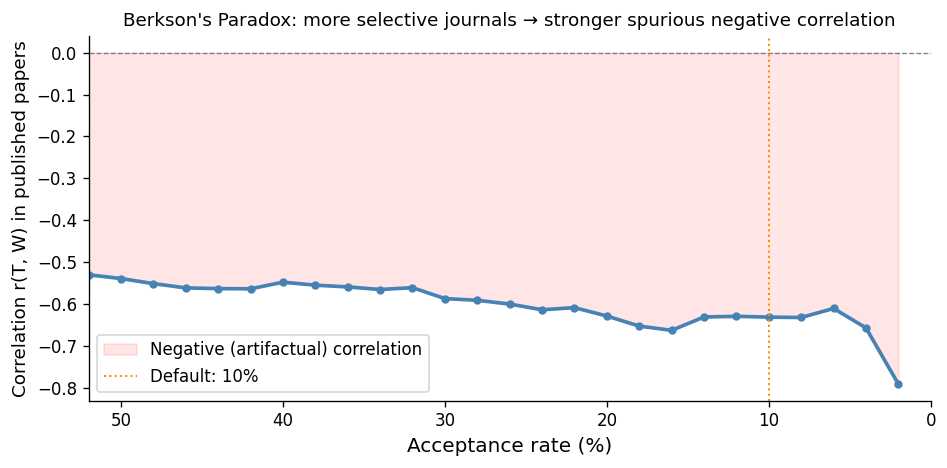

Key finding: The more selective the journal, the stronger the Berkson effect.
Top journals paradoxically produce the most distorted views of trustworthiness.


In [6]:
# ── Sweep acceptance rates ────────────────────────────────────────────────
acceptance_rates = np.arange(0.02, 0.55, 0.02)   # 2% to 50%
correlations     = []

for rate in acceptance_rates:
    n_top = max(2, round(M * rate))          # need at least 2 points for correlation
    sel_idx = ranked_indices[:n_top]
    r, _ = stats.pearsonr(newsworthiness[sel_idx], trustworthiness[sel_idx])
    correlations.append(r)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(acceptance_rates * 100, correlations,
        color="steelblue", linewidth=2.2, marker="o", markersize=4)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.fill_between(acceptance_rates * 100, correlations, 0,
                where=[c < 0 for c in correlations],
                color="red", alpha=0.1, label="Negative (artifactual) correlation")

ax.set_xlabel("Acceptance rate (%)", fontsize=12)
ax.set_ylabel("Correlation r(T, W) in published papers", fontsize=11)
ax.set_title("Berkson's Paradox: more selective journals → stronger spurious negative correlation",
             fontsize=11)
ax.set_xlim(0, 52); ax.legend(fontsize=10)
ax.invert_xaxis()   # left = most selective, right = least selective

# Annotate the model's default (10%)
ax.axvline(10, color="darkorange", linestyle=":", linewidth=1.2, label="Default: 10%")
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("Key finding: The more selective the journal, the stronger the Berkson effect.")
print("Top journals paradoxically produce the most distorted views of trustworthiness.")


## 📝 Key Takeaways

| Concept | What this simulation shows |
|---------|--------------------------|
| **Berkson's Paradox** | Conditioning on a collider (publication) induces spurious correlations |
| **T and W are independent** | In the full population, no relation — verified with r ≈ 0 |
| **Published papers: negative r** | High newsworthiness compensates for low trustworthiness, and vice versa |
| **More selective = worse distortion** | Elite journals distort the science-public interface the most |
| **No bad actors required** | This happens even with well-intentioned reviewers picking the "best" papers |

### The Decline Effect explained

When a flashy result is first published, it tends to have high W and may have moderate T.  
Follow-up replications (often more rigorous, less spectacular) tend to find smaller effects —  
not because science is broken, but because **the original result was selected partly for its extremity**.

